# EN3160 L03 — Building a Gaussian Kernel by Hand
Two parts:
1. The continuous 3D surface plot (matches the screenshot you shared) — good for *intuition*, but this isn't the actual discrete kernel you'd use in `cv.filter2D`.
2. The actual small discrete kernel (e.g. 3x3 or 7x7) that you'd construct by hand for Tutorial-style questions, with the un-normalized values, the normalization step, and a check that it sums to 1.

## Setup

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


## 1. Continuous Gaussian surface (matches the shared screenshot)
This samples the *continuous* formula `G(x,y) = 1/(2*pi*sigma^2) * exp(-(x^2+y^2)/(2*sigma^2))` on a fine grid, purely to visualize the bell shape. Try changing `sigma` and rerunning to see how the width of the bump changes.

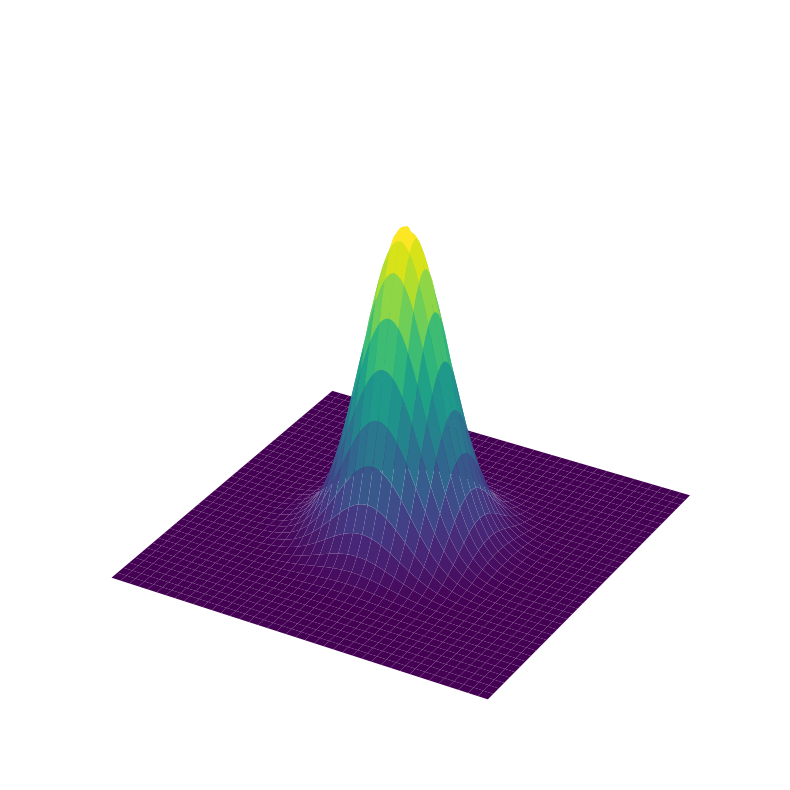

In [2]:
sigma = 2.0

x = np.arange(-10, 10.1, 0.1)
y = np.arange(-10, 10.1, 0.1)
X, Y = np.meshgrid(x, y)

# the constant factor out front (1/(2*pi*sigma^2)) only scales the HEIGHT of the peak -
# it does not change the shape. It matters here because we're plotting the true continuous
# function, but note that when building a discrete filtering kernel (part 2 below) we drop
# this constant and renormalize by the kernel's own sum instead - same reasoning as your
# lecture notes.
g = 1 / (2 * np.pi * sigma**2) * np.exp(-(X**2 + Y**2) / (2 * sigma**2))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, g, cmap='viridis')
plt.axis('off')
plt.show()


### Try this: overlay two sigmas
Compare a small sigma (narrow, tall peak) against a large sigma (wide, flat peak) — this is the practical picture behind the '3-sigma half-width' rule of thumb from your study guide.

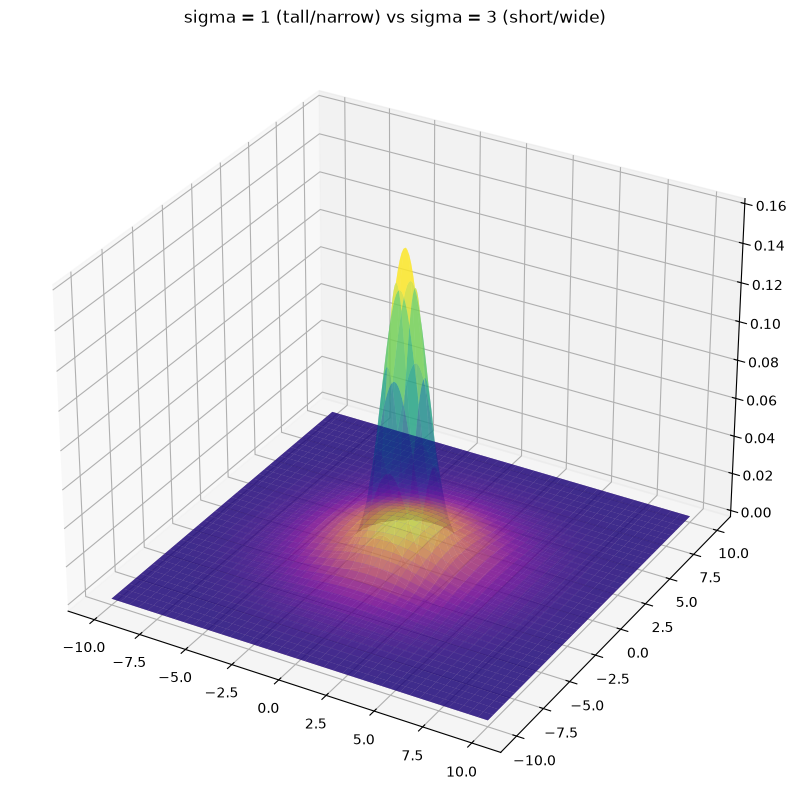

In [3]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

for sigma_val, cmap in [(1.0, 'viridis'), (3.0, 'plasma')]:
    g_compare = 1 / (2 * np.pi * sigma_val**2) * np.exp(-(X**2 + Y**2) / (2 * sigma_val**2))
    ax.plot_surface(X, Y, g_compare, cmap=cmap, alpha=0.6)

ax.set_title('sigma = 1 (tall/narrow) vs sigma = 3 (short/wide)')
plt.show()


## 2. The actual discrete kernel (what you build by hand for the tutorial)
This is a small, finite kernel — e.g. 3x3 or 7x7 — built by evaluating the Gaussian formula only at INTEGER offsets from the center, then normalizing so the kernel sums to 1.

Set `size` to an odd number (3, 5, 7, ...) and `sigma` to whatever your question specifies.

In [4]:
def gaussian_kernel_1d(size, sigma):
    """Returns an un-normalized 1D Gaussian kernel of the given odd size."""
    half = size // 2
    coords = np.arange(-half, half + 1)               # e.g. size=3 -> [-1, 0, 1]
    kernel = np.exp(-(coords**2) / (2 * sigma**2))     # constant factor dropped on purpose
    return kernel, coords

size = 3
sigma = 1.0

kernel_1d, coords = gaussian_kernel_1d(size, sigma)
print("coordinates:      ", coords)
print("un-normalized 1D: ", kernel_1d)
print("sum before norm:  ", kernel_1d.sum())


coordinates:       [-1  0  1]
un-normalized 1D:  [0.60653066 1.         0.60653066]
sum before norm:   2.213061319425267


### Normalize the 1D kernel
Divide by the kernel's own sum so the total is exactly 1 — this is what prevents a flat white region from getting brighter (overflowing) after filtering.

In [5]:
kernel_1d_norm = kernel_1d / kernel_1d.sum()
print("normalized 1D kernel:", kernel_1d_norm)
print("sum after norm:      ", kernel_1d_norm.sum())


normalized 1D kernel: [0.27406862 0.45186276 0.27406862]
sum after norm:       1.0


### Build the 2D kernel as the outer product of the 1D kernel with itself
This is the separability property from your study guide (L03 section 10) — a 2D Gaussian kernel is exactly the outer product of two identical 1D Gaussian kernels. Confirm the result sums to 1 and matches the manual 3x3 worked example (sigma=1) from your notes.

In [6]:
kernel_2d = np.outer(kernel_1d_norm, kernel_1d_norm)

print("2D kernel:")
print(kernel_2d)
print("\nsum of 2D kernel:", kernel_2d.sum())


2D kernel:
[[0.07511361 0.1238414  0.07511361]
 [0.1238414  0.20417996 0.1238414 ]
 [0.07511361 0.1238414  0.07511361]]

sum of 2D kernel: 1.0000000000000002


### Visualize the small discrete kernel
Two views of the same small kernel: a heatmap (easiest to read exact values off) and a bar3d plot (closer to the continuous-surface look, but you can now see the individual discrete kernel cells instead of a smooth curve).

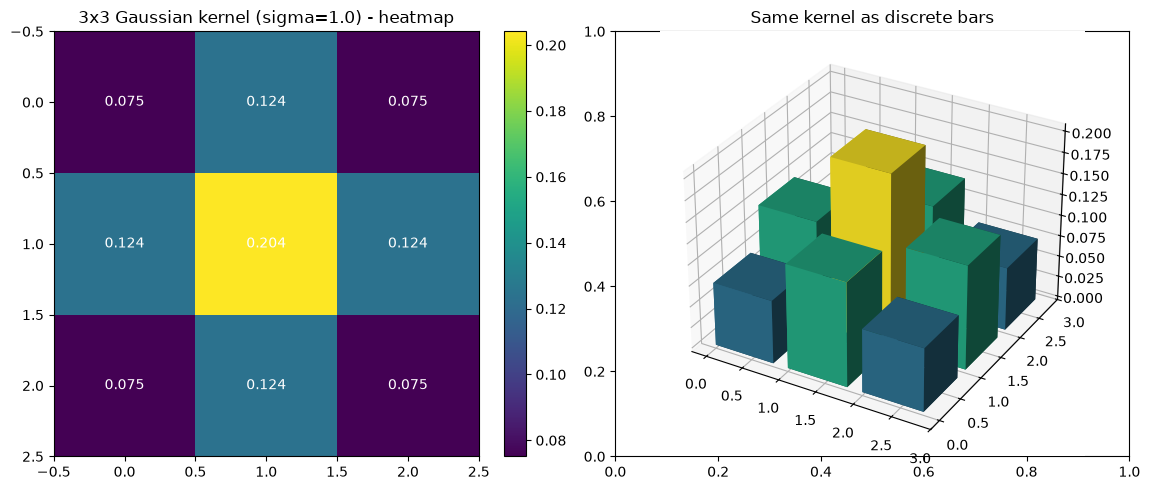

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

im0 = ax[0].imshow(kernel_2d, cmap='viridis')
ax[0].set_title(f'{size}x{size} Gaussian kernel (sigma={sigma}) - heatmap')
for i in range(size):
    for j in range(size):
        ax[0].text(j, i, f'{kernel_2d[i, j]:.3f}', ha='center', va='center', color='white')
plt.colorbar(im0, ax=ax[0], fraction=0.046)

ax[1] = fig.add_subplot(1, 2, 2, projection='3d')
xpos, ypos = np.meshgrid(np.arange(size), np.arange(size))
xpos, ypos = xpos.flatten(), ypos.flatten()
zpos = np.zeros_like(xpos)
dx = dy = 0.8
dz = kernel_2d.flatten()
ax[1].bar3d(xpos, ypos, zpos, dx, dy, dz, shade=True, color=plt.cm.viridis(dz / dz.max()))
ax[1].set_title('Same kernel as discrete bars')

plt.tight_layout()
plt.show()


### Apply the kernel to a real image with `cv.filter2D`
Once you trust the kernel values, this is how you'd actually use them — same pattern as the averaging/Sobel examples earlier.

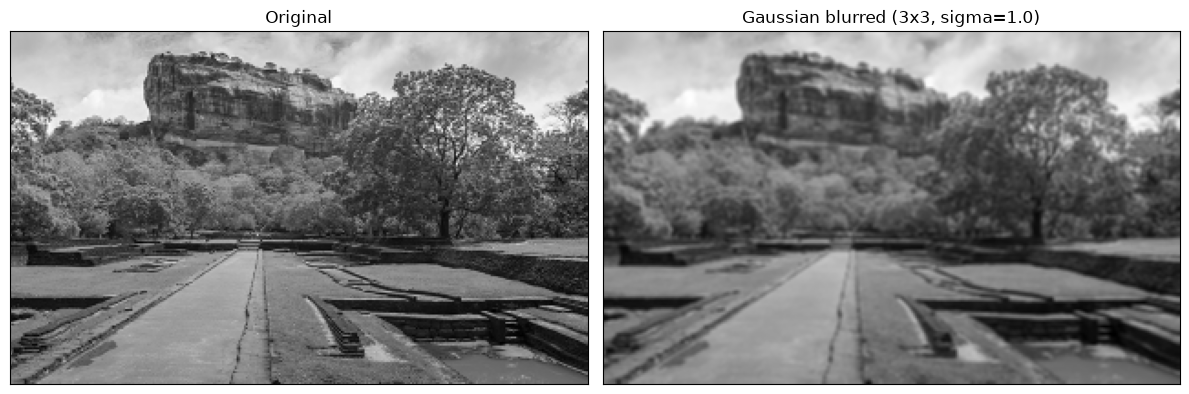

In [9]:
im = cv.imread("D:\Abdul Rahman\Engineering_UOM\.Sem 5\EN3160 - Image Processing and Computer Vision\EN3160-Image-processing-and-Machine-Vision\images\sigiriya.jpg", cv.IMREAD_REDUCED_GRAYSCALE_2)
assert im is not None

im_blurred = cv.filter2D(im, cv.CV_32F, kernel_2d.astype(np.float32))

fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharex='all', sharey='all')
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original')
ax[1].imshow(im_blurred, cmap='gray')
ax[1].set_title(f'Gaussian blurred ({size}x{size}, sigma={sigma})')
for a in ax:
    a.set_xticks([]), a.set_yticks([])
plt.tight_layout()
plt.show()


### Sanity check: compare your hand-built kernel against OpenCV's own
`cv.getGaussianKernel` returns OpenCV's 1D Gaussian kernel for a given size/sigma — a good way to confirm your manual construction is correct, independent of your own code.

In [11]:
cv_kernel_1d = cv.getGaussianKernel(size, sigma).flatten()

print("your kernel:      ", kernel_1d_norm)
print("cv.getGaussianKernel:", cv_kernel_1d)
print("match:", np.allclose(kernel_1d_norm, cv_kernel_1d, atol=1e-6))


your kernel:       [0.27406862 0.45186276 0.27406862]
cv.getGaussianKernel: [0.27406862 0.45186276 0.27406862]
match: True
